**01. Data Acquisition & Initial Setup**


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('credit_card_churn.csv')

# Display first 5 rows to understand the structure
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


**02. Data Cleaning & Integration (Preprocessing)**

In [3]:
# Drop unnecessary columns that don't support decision making
# Removing the last two columns as discussed in lecture slides
df = df.drop(df.columns[-2:], axis=1)

# Removing Client Number as it's a unique identifier and doesn't provide analytical value
df = df.drop('CLIENTNUM', axis=1)

# Check for missing values in the dataset
print("Missing Values per Column:")
print(df.isnull().sum())

Missing Values per Column:
Attrition_Flag              0
Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Avg_Open_To_Buy             0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Amt             0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
dtype: int64


**03. Descriptive Analytics**


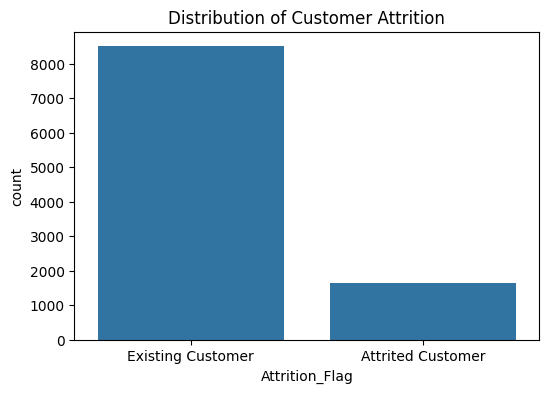

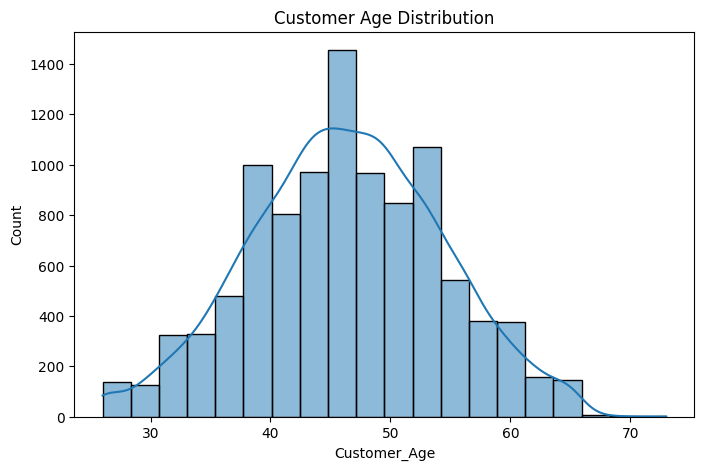

In [4]:
import seaborn as sns

# Visualizing the distribution of Churned vs Existing Customers
plt.figure(figsize=(6,4))
sns.countplot(x='Attrition_Flag', data=df)
plt.title('Distribution of Customer Attrition')
plt.show()

# Checking Age distribution of customers
plt.figure(figsize=(8,5))
sns.histplot(df['Customer_Age'], bins=20, kde=True)
plt.title('Customer Age Distribution')
plt.show()

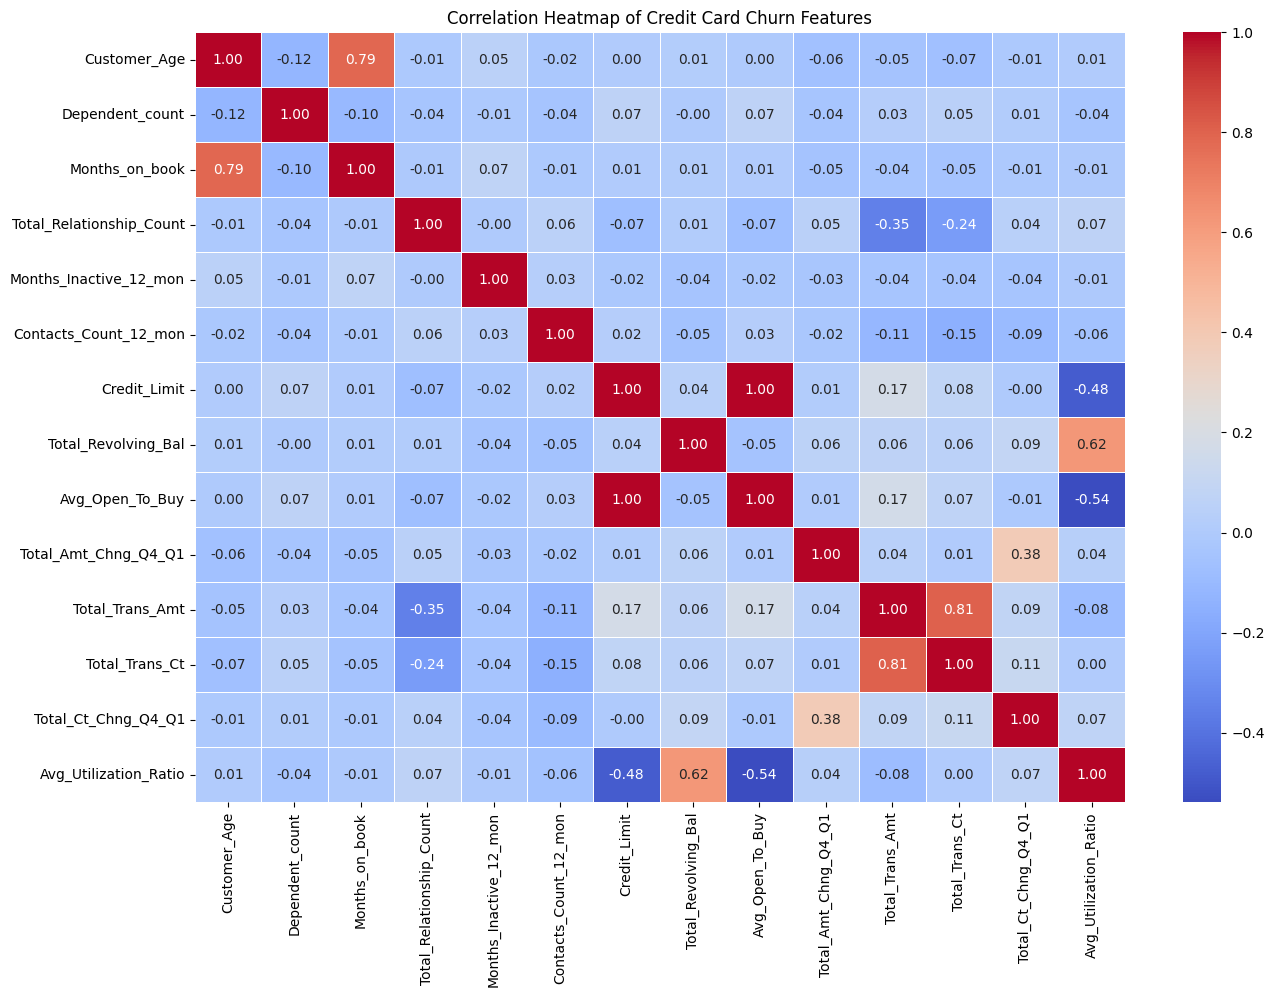

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


corr_matrix = df.corr(numeric_only=True)

# Heatmap එක ඇඳීම
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Credit Card Churn Features')
plt.show()


 **04: Data Transformation (Encoding)**


In [6]:
from sklearn.preprocessing import LabelEncoder

# LabelEncoder use & categorical data conver to the  numbers
le = LabelEncoder()

# coloum in letters  (Object columns) haduna genima
categorical_cols = df.select_dtypes(include=['object']).columns

# every coloum convert to number value
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("Data Transformation Successful!")
df.head()

Data Transformation Successful!


,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,1,45,1,3,3,1,2,0,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,1,49,0,5,2,2,4,0,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,1,51,1,3,2,1,3,0,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,1,40,0,4,3,3,4,0,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,1,40,1,3,5,1,2,0,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


**05. Data Mining - Classification**

In [7]:
# Import necessary tools for Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Define features (X) and target (y)
# 'Attrition_Flag' is our target variable for churn prediction
X = df.drop('Attrition_Flag', axis=1)
y = df['Attrition_Flag']

# Split data into Training set (80%) and Testing set (20%)
# This ensures we can evaluate the model on unseen data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Random Forest Classifier
# Random Forest is an ensemble learning method as discussed in data mining techniques
model = RandomForestClassifier(n_estimators=100)

# Train the model using the training data
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate and display the Model Accuracy
# Accuracy is a key metric in evaluating ML models as per the KDD process [cite: 3074]
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

# Generate a detailed classification report (Precision, Recall, F1-score)
# This is part of the Pattern Evaluation phase in KDD [cite: 3017, 3022]
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 95.61%

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.79      0.85       327
           1       0.96      0.99      0.97      1699

    accuracy                           0.96      2026
   macro avg       0.94      0.89      0.91      2026
weighted avg       0.96      0.96      0.95      2026



**5.1 Confusion Matrix**

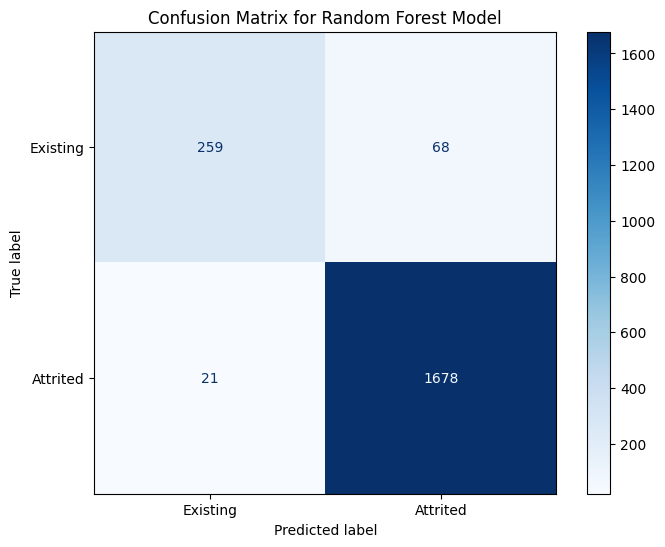

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


cm = confusion_matrix(y_test, y_pred)


fig, ax = plt.subplots(figsize=(8, 6))


disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Existing', 'Attrited'])
disp.plot(cmap='Blues', values_format='d', ax=ax)

plt.title('Confusion Matrix for Random Forest Model')
plt.show()

**5.2 Additional Classification Models**


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

print("Logistic Regression Results")
print("-" * 40)
print("Accuracy:", round(accuracy_score(y_test, y_pred_log) * 100, 2), "%")
print(classification_report(y_test, y_pred_log))

# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Results")
print("-" * 40)
print("Accuracy:", round(accuracy_score(y_test, y_pred_dt) * 100, 2), "%")
print(classification_report(y_test, y_pred_dt))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Results
----------------------------------------
Accuracy: 88.6 %
              precision    recall  f1-score   support

           0       0.73      0.46      0.57       327
           1       0.90      0.97      0.93      1699

    accuracy                           0.89      2026
   macro avg       0.82      0.72      0.75      2026
weighted avg       0.88      0.89      0.88      2026

Decision Tree Results
----------------------------------------
Accuracy: 93.29 %
              precision    recall  f1-score   support

           0       0.80      0.79      0.79       327
           1       0.96      0.96      0.96      1699

    accuracy                           0.93      2026
   macro avg       0.88      0.87      0.88      2026
weighted avg       0.93      0.93      0.93      2026



**5.3 Model Comparison**

In [10]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred)
    ],
    'Precision': [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred)
    ],
    'Recall': [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred)
    ],
    'F1-score': [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred)
    ]
})

print(comparison)

                 Model  Accuracy  Precision    Recall  F1-score
0  Logistic Regression  0.885982   0.903740  0.967039  0.934319
1        Decision Tree  0.932873   0.958896  0.961154  0.960024
2        Random Forest  0.956071   0.961054  0.987640  0.974165


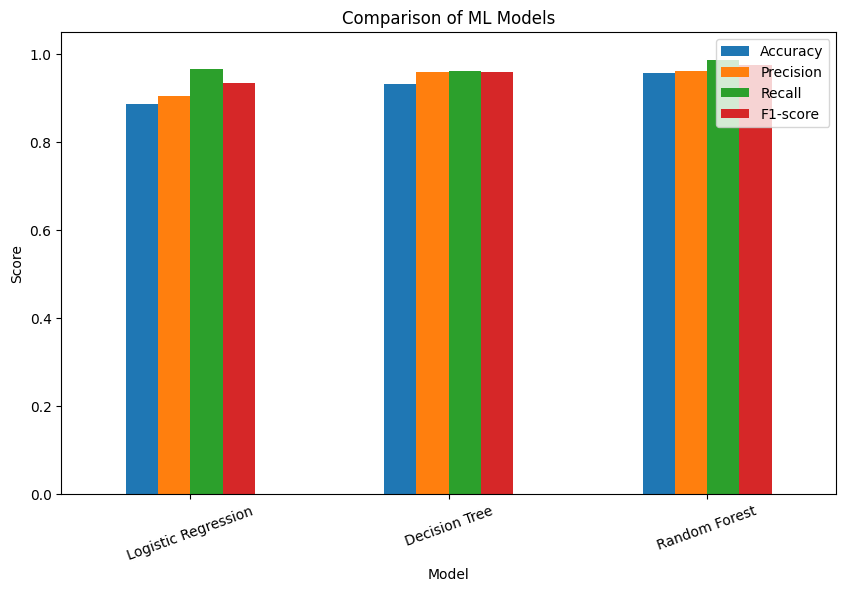

In [11]:
comparison.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-score']].plot(
    kind='bar', figsize=(10,6)
)
plt.title('Comparison of ML Models')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.show()

**6: Pattern Evaluation (Feature Importance)**

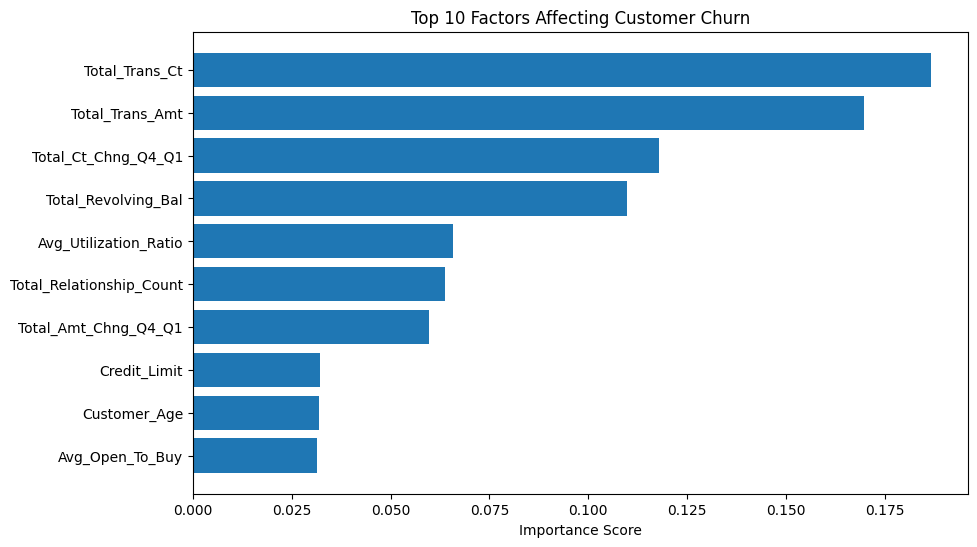

In [17]:
# Extract and plot feature importance to evaluate the patterns discovered [cite: 3074]
import matplotlib.pyplot as plt

# Get importance levels from the trained model
importances = model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Visualize the top factors affecting churn
plt.figure(figsize=(10,6))
plt.barh(feature_importance_df['Feature'][:10], feature_importance_df['Importance'][:10])
plt.xlabel('Importance Score')
plt.title('Top 10 Factors Affecting Customer Churn')
plt.gca().invert_yaxis() # Invert y-axis to show the highest importance at the top
plt.show()

**07. Data Mining - Clustering (Using   K-Means algorithm)**

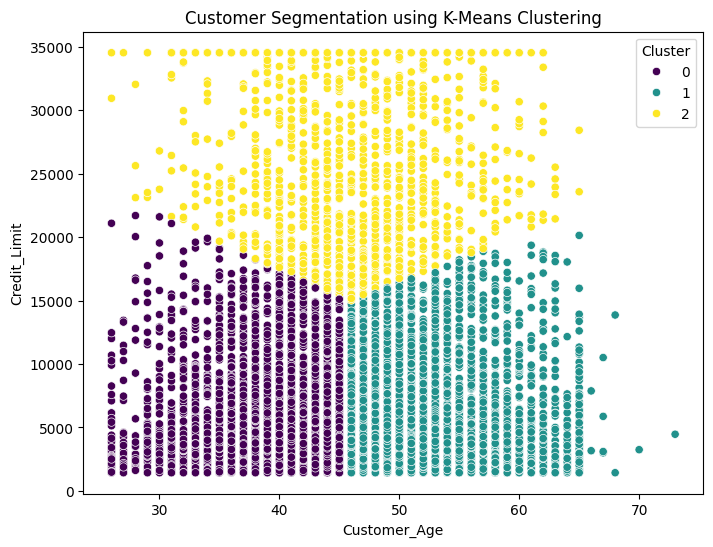

Clustering Completed and Segments Identified!


In [ ]:
# Import KMeans for clustering
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Selecting features for clustering (Age and Credit Limit)
# Clustering finds similarities between data objects based on characteristics
cluster_data = df[['Customer_Age', 'Credit_Limit']]

# Standardizing the data is important for K-Means to perform well
scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_data)

# Initializing KMeans with 3 clusters (K=3)
# We arbitrarily choose K or use methods like the Elbow method
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_data)

# Visualizing the clusters
plt.figure(figsize=(8,6))
sns.scatterplot(x='Customer_Age', y='Credit_Limit', hue='Cluster', data=df, palette='viridis')
plt.title('Customer Segmentation using K-Means Clustering')
plt.show()

print("Clustering Completed and Segments Identified!")

**08: Association Analysis**

Association Insight (Card Category vs Churn):
Attrition_Flag         0         1
Card_Category                     
0               0.160979  0.839021
1               0.181034  0.818966
2               0.250000  0.750000
3               0.147748  0.852252


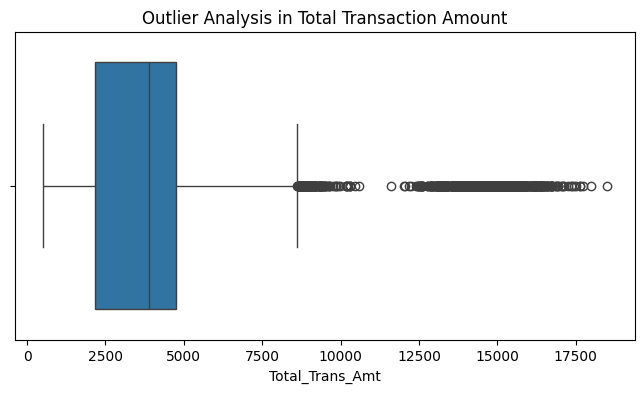

In [ ]:
# 1. Association Insight: Checking relationship between Card Category and Churn
# Association mining finds causal structures among sets of items [cite: 17]
association_pivot = pd.crosstab(df['Card_Category'], df['Attrition_Flag'], normalize='index')
print("Association Insight (Card Category vs Churn):")
print(association_pivot)

# 2. Outlier Analysis: Identifying unusual high transactions
# Outliers are objects that do not comply with the general behavior of data
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Total_Trans_Amt'])
plt.title('Outlier Analysis in Total Transaction Amount')
plt.show()

**09:Outlier Analysis**

Number of outliers in Credit_Limit: 984


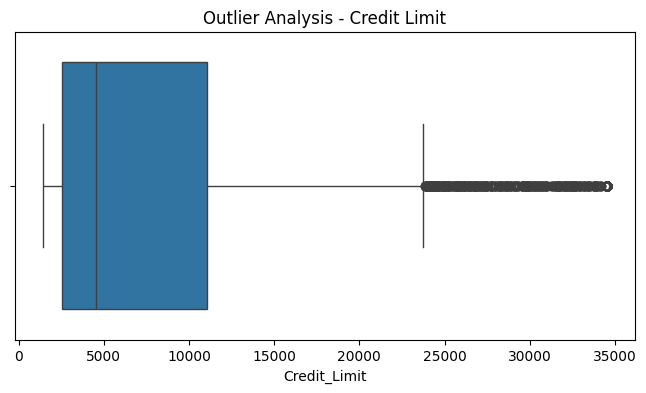

In [16]:
Q1_cl = df['Credit_Limit'].quantile(0.25)
Q3_cl = df['Credit_Limit'].quantile(0.75)
IQR_cl = Q3_cl - Q1_cl

lower_cl = Q1_cl - 1.5 * IQR_cl
upper_cl = Q3_cl + 1.5 * IQR_cl

outliers_cl = df[(df['Credit_Limit'] < lower_cl) | (df['Credit_Limit'] > upper_cl)]

print("Number of outliers in Credit_Limit:", outliers_cl.shape[0])

plt.figure(figsize=(8,4))
sns.boxplot(x=df['Credit_Limit'])
plt.title('Outlier Analysis - Credit Limit')
plt.show()

**10:Download Cleaned Data Set**

In [ ]:
# Download the final cleaned and clustered dataset for Power BI
df.to_csv('final_bank_churn_data.csv', index=False)
from google.colab import files
files.download('final_bank_churn_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>